In [32]:
# =========================================================
# 1. Imports
# =========================================================

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
from catboost import CatBoostRegressor

# Display settings
sns.set_style("darkgrid", rc={"axes.facecolor": "white", "grid.color": ".8"})
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

In [33]:
# =========================================================
# 2. Load data
# =========================================================

# Load the feature dataset and parse the timestamp column as datetime
df = pd.read_csv("../data/df_features.csv", parse_dates=["timestamp"])

# Sort the data chronologically and reset the index
df = df.sort_values("timestamp").reset_index(drop=True)

# Show basic checks
print("Shape:", df.shape)
print("Date range:", df["timestamp"].min(), "to", df["timestamp"].max())
display(df.head(2))

Shape: (62544, 60)
Date range: 2019-01-16 00:00:00 to 2026-03-05 23:00:00


,timestamp,price,load,wind_offshore,wind_onshore,solar,hour,day_of_week,month,temperature,wind_speed,is_weekend,gas_price,coal_price,price_lag_24h,price_lag_168h,price_rolling_24h,price_rolling_168h,co2_price,is_holiday,is_hol_or_week,total_generation,net_export,coal_generation,gas_generation,nuclear_generation,actual_wind_offshore,actual_wind_onshore,actual_solar,actual_load,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,gas_price_lag_24h,gas_price_lag_168h,coal_price_lag_24h,coal_price_lag_168h,co2_price_lag_24h,renewable_share,fuel_cost_index,dispatchable_gen,demand_supply_gap,is_peak_hour,wind_x_peak,gas_x_peak,solar_x_demand,renewable_share_x_peak,is_crisis_period,is_high_price_regime,is_negative_price,year,residual_load,load_ramp,renewable_ramp,price_volatility_24h,total_wind_forecast,delta_wind_forecast
0,2019-01-16 00:00:00,29.23,54295.0,4647.00,26771.75,0.0,0.0,2.0,1.0,4.9125,36.267860,False,22.004999,83.0,35.18,20.04,45.200000,41.705119,22.81,False,False,69793.75,10571.0,13605.00,5162.5,8970.75,3558.75,30280.00,0.0,55014.00,0.000000,1.000000,0.974928,-0.222521,0.5,0.866025,22.0,21.719999,82.5,82.150002,22.55,0.450166,46.402999,27738.25,-15498.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019.0,22876.25,-2525.75,-2456.25,9.645450,31418.75,1551.5
1,2019-01-16 01:00:00,29.26,52450.0,4561.25,26022.25,0.0,1.0,2.0,1.0,4.8000,34.451492,False,22.004999,83.0,35.82,7.24,44.926667,41.836190,22.81,False,False,67991.75,11379.0,13050.75,4994.5,8959.00,3603.00,29191.25,0.0,52838.75,0.258819,0.965926,0.974928,-0.222521,0.5,0.866025,22.0,21.719999,82.5,82.150002,22.55,0.449812,46.402999,27004.25,-15541.75,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019.0,21866.50,-1845.00,-835.25,10.008918,30583.50,510.5


In [34]:
# =========================================================
# 3. Define the final feature set
# =========================================================

# Define the final feature set after removing the teammate-flagged leakage features
feature_cols = [
    "load",
    "wind_offshore",
    "wind_onshore",
    "solar",
    "hour",
    "day_of_week",
    "month",
    "temperature",
    "wind_speed",
    "is_weekend",
    "price_lag_24h",
    "price_lag_168h",
    "price_rolling_24h",
    "price_rolling_168h",
    "is_holiday",
    "is_hol_or_week",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
    "gas_price_lag_24h",
    "gas_price_lag_168h",
    "coal_price_lag_24h",
    "coal_price_lag_168h",
    "co2_price_lag_24h",
    #"fuel_cost_index",
    "is_peak_hour",
    "wind_x_peak",
    #"gas_x_peak",
    "solar_x_demand",
    #"renewable_share_x_peak",
    "is_crisis_period",
    "is_high_price_regime",
    "year",
    "price_volatility_24h",
    "total_wind_forecast",
    "delta_wind_forecast"
]

In [35]:
# =========================================================
# 4. Check the selected feature set
# =========================================================

# Check whether all selected features exist in the dataframe
missing_features = [col for col in feature_cols if col not in df.columns]

# Print missing features
print("Missing features:", missing_features)

# Print number of selected features
print("Number of selected features:", len(feature_cols))

# Show the selected feature names
print(feature_cols)

# Preview the selected feature columns
display(df[feature_cols].head(2))

# Show data type counts
display(df[feature_cols].dtypes.value_counts())

# Show missing values in the selected features
display(df[feature_cols].isna().sum().sort_values(ascending=False).head(20))

Missing features: []
Number of selected features: 36
['load', 'wind_offshore', 'wind_onshore', 'solar', 'hour', 'day_of_week', 'month', 'temperature', 'wind_speed', 'is_weekend', 'price_lag_24h', 'price_lag_168h', 'price_rolling_24h', 'price_rolling_168h', 'is_holiday', 'is_hol_or_week', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'gas_price_lag_24h', 'gas_price_lag_168h', 'coal_price_lag_24h', 'coal_price_lag_168h', 'co2_price_lag_24h', 'is_peak_hour', 'wind_x_peak', 'solar_x_demand', 'is_crisis_period', 'is_high_price_regime', 'year', 'price_volatility_24h', 'total_wind_forecast', 'delta_wind_forecast']


,load,wind_offshore,wind_onshore,solar,hour,day_of_week,month,temperature,wind_speed,is_weekend,price_lag_24h,price_lag_168h,price_rolling_24h,price_rolling_168h,is_holiday,is_hol_or_week,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,gas_price_lag_24h,gas_price_lag_168h,coal_price_lag_24h,coal_price_lag_168h,co2_price_lag_24h,is_peak_hour,wind_x_peak,solar_x_demand,is_crisis_period,is_high_price_regime,year,price_volatility_24h,total_wind_forecast,delta_wind_forecast
0,54295.0,4647.00,26771.75,0.0,0.0,2.0,1.0,4.9125,36.267860,False,35.18,20.04,45.200000,41.705119,False,False,0.000000,1.000000,0.974928,-0.222521,0.5,0.866025,22.0,21.719999,82.5,82.150002,22.55,0.0,0.0,0.0,0.0,0.0,2019.0,9.645450,31418.75,1551.5
1,52450.0,4561.25,26022.25,0.0,1.0,2.0,1.0,4.8000,34.451492,False,35.82,7.24,44.926667,41.836190,False,False,0.258819,0.965926,0.974928,-0.222521,0.5,0.866025,22.0,21.719999,82.5,82.150002,22.55,0.0,0.0,0.0,0.0,0.0,2019.0,10.008918,30583.50,510.5


float64    33
bool        3
Name: count, dtype: int64

load                    0
wind_offshore           0
month_sin               0
month_cos               0
gas_price_lag_24h       0
gas_price_lag_168h      0
coal_price_lag_24h      0
coal_price_lag_168h     0
co2_price_lag_24h       0
is_peak_hour            0
wind_x_peak             0
solar_x_demand          0
is_crisis_period        0
is_high_price_regime    0
year                    0
price_volatility_24h    0
total_wind_forecast     0
dow_cos                 0
dow_sin                 0
hour_cos                0
dtype: int64

In [36]:
# =========================================================
# 5. Create the hourly train, validation, and test split
# =========================================================

# Create chronological masks
train_mask = df["timestamp"] < "2025-01-01"
val_mask = (df["timestamp"] >= "2025-01-01") & (df["timestamp"] < "2025-07-01")
test_mask = df["timestamp"] >= "2025-07-01"

# Create split dataframes
train_df = df.loc[train_mask].copy()
val_df = df.loc[val_mask].copy()
test_df = df.loc[test_mask].copy()

# Show split shapes
print("train_df:", train_df.shape)
print("val_df:", val_df.shape)
print("test_df:", test_df.shape)

train_df: (52248, 60)
val_df: (4344, 60)
test_df: (5952, 60)


In [37]:
# =========================================================
# 6. Create sample weights for the training period
# =========================================================

# Create default training weights
train_weights = pd.Series(1.0, index=train_df.index)

# Assign regime-based weights
train_weights.loc[(train_df["timestamp"] >= "2019-01-01") & (train_df["timestamp"] < "2021-01-01")] = 0.6
train_weights.loc[(train_df["timestamp"] >= "2021-01-01") & (train_df["timestamp"] < "2023-01-01")] = 0.3
train_weights.loc[(train_df["timestamp"] >= "2023-01-01") & (train_df["timestamp"] < "2025-01-01")] = 1.0

# Show the weight distribution
display(train_weights.value_counts().sort_index())
display(train_weights.head())

0.3    17520
0.6    17184
1.0    17544
Name: count, dtype: int64

0    0.6
1    0.6
2    0.6
3    0.6
4    0.6
dtype: float64

In [38]:
# =========================================================
# 7. Create hourly feature matrices and targets
# =========================================================

# Create feature matrices
X_train = train_df[feature_cols].copy()
X_val = val_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

# Create targets
y_train = train_df["price"].copy()
y_val = val_df["price"].copy()
y_test = test_df["price"].copy()

# Show shapes
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (52248, 36)
X_val: (4344, 36)
X_test: (5952, 36)
y_train: (52248,)
y_val: (4344,)
y_test: (5952,)


In [39]:
# =========================================================
# 8. Build the naive hourly benchmark
# =========================================================

# Define a function for the naive hourly forecast
def predict_price_lag_hourly(df_input, price_col="price", day_col="day_of_week"):
    # Create 24-hour and 168-hour lagged prices
    lag_1 = df_input[price_col].shift(24)
    lag_7 = df_input[price_col].shift(168)

    # Use D-1 for Tue, Wed, Thu, Fri, Sun and D-7 for Mon, Sat
    lag_1_days = {1, 2, 3, 4, 6}

    # Return the naive prediction series
    return pd.Series(
        np.where(df_input[day_col].isin(lag_1_days), lag_1, lag_7),
        index=df_input.index
    )

# Create naive hourly predictions for the full dataframe
df["price_pred_naive"] = predict_price_lag_hourly(df)

# Extract naive predictions for validation and test
y_val_naive = df.loc[val_df.index, "price_pred_naive"].copy()
y_test_naive = df.loc[test_df.index, "price_pred_naive"].copy()

In [40]:
# =========================================================
# 9. Define evaluation metrics
# =========================================================

# Define hourly MAE
def mae_hourly(y_true, y_pred):
    # Compute the mean absolute error
    return mean_absolute_error(y_true, y_pred)

# Define daily average error based on hourly predictions
def dae_hourly(y_true, y_pred, timestamps):
    # Build a temporary dataframe with timestamps, true values, and predictions
    eval_df = pd.DataFrame({
        "timestamp": timestamps,
        "y_true": y_true,
        "y_pred": y_pred
    })

    # Aggregate to daily sums
    daily_eval = eval_df.groupby(eval_df["timestamp"].dt.floor("D")).agg({
        "y_true": "sum",
        "y_pred": "sum"
    })

    # Compute the mean daily average error
    return np.mean(np.abs(daily_eval["y_true"] - daily_eval["y_pred"]) / 24)

# Define relative MAE against the naive benchmark
def rmae(model_mae, naive_mae):
    # Compute relative MAE
    return model_mae / naive_mae

In [41]:
# =========================================================
# 10. Evaluate the naive benchmark
# =========================================================

# Compute naive validation metrics
naive_val_mae = mae_hourly(y_val, y_val_naive)
naive_val_dae = dae_hourly(y_val, y_val_naive, val_df["timestamp"])

# Compute naive test metrics
naive_test_mae = mae_hourly(y_test, y_test_naive)
naive_test_dae = dae_hourly(y_test, y_test_naive, test_df["timestamp"])

# Print validation results
print("Naive validation MAE:", round(naive_val_mae, 4))
print("Naive validation DAE:", round(naive_val_dae, 4))

# Print test results
print("Naive test MAE:", round(naive_test_mae, 4))
print("Naive test DAE:", round(naive_test_dae, 4))

Naive validation MAE: 28.4164
Naive validation DAE: 22.57
Naive test MAE: 23.3474
Naive test DAE: 18.8407


In [42]:
# =========================================================
# 11. Build the Lasso benchmark
# =========================================================

# Build a pipeline with feature scaling and Lasso
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.01, max_iter=10000, random_state=42))
])

# Fit the Lasso model on the training data with sample weights
lasso_model.fit(X_train, y_train, model__sample_weight=train_weights)

# Predict on validation and test data
y_val_pred_lasso = pd.Series(lasso_model.predict(X_val), index=y_val.index)
y_test_pred_lasso = pd.Series(lasso_model.predict(X_test), index=y_test.index)

In [43]:
# =========================================================
# 12. Evaluate the Lasso benchmark
# =========================================================

# Compute Lasso validation metrics
lasso_val_mae = mae_hourly(y_val, y_val_pred_lasso)
lasso_val_dae = dae_hourly(y_val, y_val_pred_lasso, val_df["timestamp"])
lasso_val_rmae = rmae(lasso_val_mae, naive_val_mae)

# Compute Lasso test metrics
lasso_test_mae = mae_hourly(y_test, y_test_pred_lasso)
lasso_test_dae = dae_hourly(y_test, y_test_pred_lasso, test_df["timestamp"])
lasso_test_rmae = rmae(lasso_test_mae, naive_test_mae)

# Print validation results
print("Lasso validation MAE:", round(lasso_val_mae, 4))
print("Lasso validation DAE:", round(lasso_val_dae, 4))
print("Lasso validation RMAE:", round(lasso_val_rmae, 4))

# Print test results
print("Lasso test MAE:", round(lasso_test_mae, 4))
print("Lasso test DAE:", round(lasso_test_dae, 4))
print("Lasso test RMAE:", round(lasso_test_rmae, 4))

Lasso validation MAE: 15.9918
Lasso validation DAE: 9.9265
Lasso validation RMAE: 0.5628
Lasso test MAE: 14.7959
Lasso test DAE: 8.5759
Lasso test RMAE: 0.6337


In [44]:
# =========================================================
# 13. Build the final CatBoost model
# =========================================================

# Combine train and validation data for final training
X_final_train = pd.concat([X_train, X_val], axis=0)
y_final_train = pd.concat([y_train, y_val], axis=0)

# Create final sample weights for the full pre-test period
val_weights = pd.Series(1.0, index=X_val.index)
final_train_weights = pd.concat([train_weights, val_weights], axis=0)

# Build the final CatBoost model with the best local tuning parameters
catboost_model = CatBoostRegressor(
    iterations=350,
    depth=8,
    learning_rate=0.10,
    l2_leaf_reg=3,
    loss_function="MAE",
    eval_metric="MAE",
    verbose=0,
    random_state=42
)

# Fit the final CatBoost model
catboost_model.fit(
    X_final_train,
    y_final_train,
    sample_weight=final_train_weights
)

# Predict on the test set
y_test_pred_catboost = pd.Series(catboost_model.predict(X_test), index=y_test.index)

In [86]:
print(type(y_test.index))
print(y_test.index[:5])
print()
print(type(y_test_pred_catboost.index))
print(y_test_pred_catboost.index[:5])

<class 'pandas.RangeIndex'>
RangeIndex(start=56592, stop=56597, step=1)

<class 'pandas.RangeIndex'>
RangeIndex(start=56592, stop=56597, step=1)


In [87]:
# Check what your original dataset looks like
print(type(X_test))
print(X_test.index[:5])
print()
print(X_test.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex(start=56592, stop=56597, step=1)

['load', 'wind_offshore', 'wind_onshore', 'solar', 'hour', 'day_of_week', 'month', 'temperature', 'wind_speed', 'is_weekend', 'price_lag_24h', 'price_lag_168h', 'price_rolling_24h', 'price_rolling_168h', 'is_holiday', 'is_hol_or_week', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'gas_price_lag_24h', 'gas_price_lag_168h', 'coal_price_lag_24h', 'coal_price_lag_168h', 'co2_price_lag_24h', 'is_peak_hour', 'wind_x_peak', 'solar_x_demand', 'is_crisis_period', 'is_high_price_regime', 'year', 'price_volatility_24h', 'total_wind_forecast', 'delta_wind_forecast']


In [88]:
# Check your original dataframe — whatever it was called before the train/test split
# Try these one by one and paste whichever works

print(df.index[:5])           # if your original dataframe was called df
print(df.columns.tolist())

RangeIndex(start=0, stop=5, step=1)
['timestamp', 'price', 'load', 'wind_offshore', 'wind_onshore', 'solar', 'hour', 'day_of_week', 'month', 'temperature', 'wind_speed', 'is_weekend', 'gas_price', 'coal_price', 'price_lag_24h', 'price_lag_168h', 'price_rolling_24h', 'price_rolling_168h', 'co2_price', 'is_holiday', 'is_hol_or_week', 'total_generation', 'net_export', 'coal_generation', 'gas_generation', 'nuclear_generation', 'actual_wind_offshore', 'actual_wind_onshore', 'actual_solar', 'actual_load', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'gas_price_lag_24h', 'gas_price_lag_168h', 'coal_price_lag_24h', 'coal_price_lag_168h', 'co2_price_lag_24h', 'renewable_share', 'fuel_cost_index', 'dispatchable_gen', 'demand_supply_gap', 'is_peak_hour', 'wind_x_peak', 'gas_x_peak', 'solar_x_demand', 'renewable_share_x_peak', 'is_crisis_period', 'is_high_price_regime', 'is_negative_price', 'year', 'residual_load', 'load_ramp', 'renewable_ramp', 'price_volatility_24h', '

In [89]:
# Extract the datetime index from the original dataframe
# using the same row positions as y_test
datetime_index = pd.to_datetime(df.loc[y_test.index, 'timestamp'])

# Rebuild both Series with proper DatetimeIndex
y_test_indexed = pd.Series(y_test.values, index=datetime_index, name='actual_price')
y_test_pred_catboost = pd.Series(
    catboost_model.predict(X_test),
    index=datetime_index,
    name='forecast_price'
)

# Verify
print(y_test_indexed.index[:3])
print(y_test_pred_catboost.index[:3])
print(f"\nDate range: {datetime_index.min().date()} → {datetime_index.max().date()}")
print(f"Total hours: {len(datetime_index)}")

DatetimeIndex(['2025-07-01 00:00:00', '2025-07-01 01:00:00', '2025-07-01 02:00:00'], dtype='datetime64[us]', name='timestamp', freq=None)
DatetimeIndex(['2025-07-01 00:00:00', '2025-07-01 01:00:00', '2025-07-01 02:00:00'], dtype='datetime64[us]', name='timestamp', freq=None)

Date range: 2025-07-01 → 2026-03-05
Total hours: 5952


In [90]:
test_dates = y_test_pred_catboost.index.normalize().unique()

print(f"Test period  : {test_dates[0].date()} → {test_dates[-1].date()}")
print(f"Trading days : {len(test_dates)}")
print(f"\nSample forecast (first day):")
print(y_test_pred_catboost[y_test_pred_catboost.index.normalize() == test_dates[0]])

Test period  : 2025-07-01 → 2026-03-05
Trading days : 248

Sample forecast (first day):
timestamp
2025-07-01 00:00:00     97.819586
2025-07-01 01:00:00     88.811477
2025-07-01 02:00:00     87.155963
2025-07-01 03:00:00     82.718067
2025-07-01 04:00:00     85.839124
2025-07-01 05:00:00     93.446462
2025-07-01 06:00:00    104.333267
2025-07-01 07:00:00    132.700587
2025-07-01 08:00:00     96.191224
2025-07-01 09:00:00     86.844150
2025-07-01 10:00:00     59.003827
2025-07-01 11:00:00     39.275312
2025-07-01 12:00:00     28.215110
2025-07-01 13:00:00     23.787432
2025-07-01 14:00:00     22.636780
2025-07-01 15:00:00     51.590164
2025-07-01 16:00:00     72.835275
2025-07-01 17:00:00     98.569667
2025-07-01 18:00:00    119.022049
2025-07-01 19:00:00    190.034234
2025-07-01 20:00:00    275.266178
2025-07-01 21:00:00    250.707304
2025-07-01 22:00:00    162.124169
2025-07-01 23:00:00    125.893726
Name: forecast_price, dtype: float64


In [45]:
# =========================================================
# 14. Evaluate the final CatBoost model with the best chosen parameters
# =========================================================

# Compute CatBoost test metrics
catboost_test_mae = mae_hourly(y_test, y_test_pred_catboost)
catboost_test_dae = dae_hourly(y_test, y_test_pred_catboost, test_df["timestamp"])
catboost_test_rmae = rmae(catboost_test_mae, naive_test_mae)

# Print final CatBoost results
print("CatBoost test MAE:", round(catboost_test_mae, 4))
print("CatBoost test DAE:", round(catboost_test_dae, 4))
print("CatBoost test RMAE:", round(catboost_test_rmae, 4))

CatBoost test MAE: 10.2135
CatBoost test DAE: 6.3964
CatBoost test RMAE: 0.4375


In [91]:
# ================================================================
# STEP 2 — Backtest over full test period (Jul 2025 – Mar 2026)
# ================================================================

optimizer = BESSOptimizer(BESSConfig())
results   = []
current_soc = optimizer.config.initial_soc_mwh  # start at 50% = 20 MWh

for date in test_dates:

    # --- slice one day of forecasts and actuals ---
    mask = y_test_pred_catboost.index.normalize() == date

    forecast = y_test_pred_catboost[mask]
    actual   = y_test_indexed[mask]

    # skip incomplete days (e.g. DST transitions or data gaps)
    if len(forecast) != 24:
        print(f"Skipping {date.date()} — only {len(forecast)} hours found")
        continue

    # --- optimise using forecast prices ---
    result = optimizer.optimize(forecast, initial_soc_mwh=current_soc)

    if result['status'] != 'Optimal':
        print(f"Warning: {date.date()} solver returned {result['status']}")
        continue

    # --- simulate against actual prices ---
    sim = optimizer.simulate(result['schedule'], actual)

    # --- carry SoC forward to next day (closure: end = start) ---
    # Under Model B the ending SoC equals the starting SoC by constraint,
    # so current_soc is unchanged. We still update explicitly for clarity.
    current_soc = result['schedule']['soc_mwh'].iloc[-1]

    # --- store results ---
    results.append({
        'date':             date.date(),
        'forecast_profit':  sim['forecast_profit'],
        'actual_profit':    sim['actual_profit'],
        'profit_gap':       sim['profit_gap'],
        'ending_soc_mwh':   current_soc,
    })

# --- compile into a DataFrame ---
backtest = pd.DataFrame(results).set_index('date')

print(f"Days optimised : {len(backtest)}")
print(f"\n--- Backtest Summary ---")
print(f"Total forecast profit : €{backtest['forecast_profit'].sum():>12,.2f}")
print(f"Total actual profit   : €{backtest['actual_profit'].sum():>12,.2f}")
print(f"Total profit gap      : €{backtest['profit_gap'].sum():>12,.2f}")
print(f"\nDaily averages:")
print(f"  Forecast profit : €{backtest['forecast_profit'].mean():>8,.2f} / day")
print(f"  Actual profit   : €{backtest['actual_profit'].mean():>8,.2f} / day")
print(f"  Profit gap      : €{backtest['profit_gap'].mean():>8,.2f} / day")
print(f"\nBest day  : €{backtest['actual_profit'].max():,.2f} on {backtest['actual_profit'].idxmax()}")
print(f"Worst day : €{backtest['actual_profit'].min():,.2f} on {backtest['actual_profit'].idxmin()}")

Days optimised : 248

--- Backtest Summary ---
Total forecast profit : €  776,762.24
Total actual profit   : €  782,311.65
Total profit gap      : €   -5,549.41

Daily averages:
  Forecast profit : €3,132.11 / day
  Actual profit   : €3,154.48 / day
  Profit gap      : €  -22.38 / day

Best day  : €12,367.55 on 2025-07-01
Worst day : €139.99 on 2025-10-04


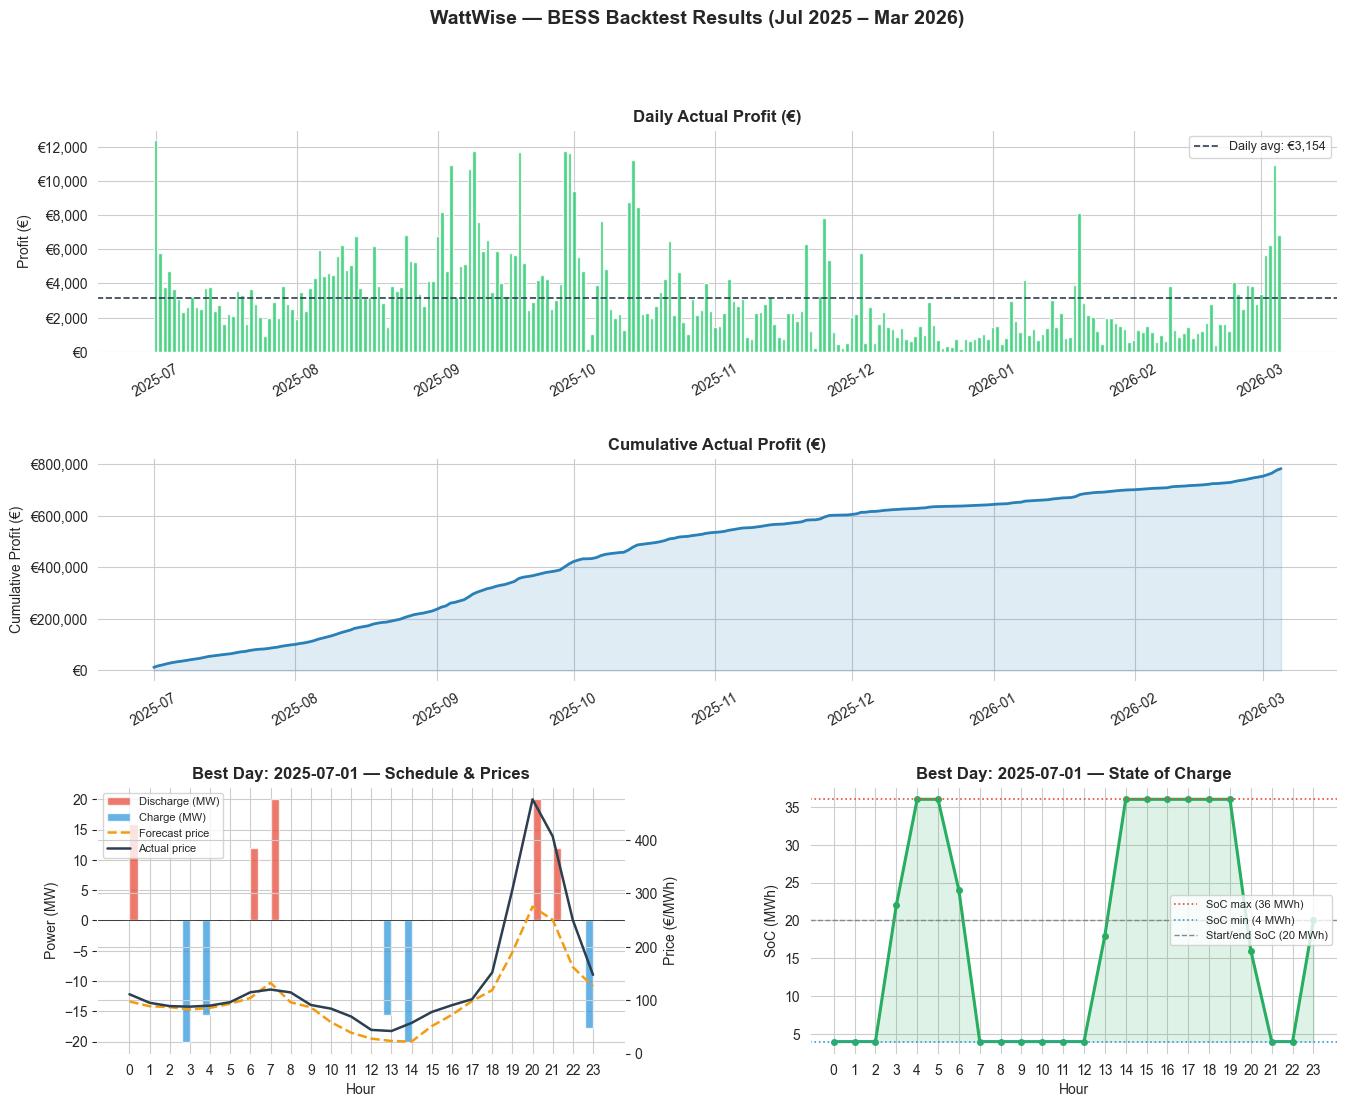

Plot saved → results/plots/bess_backtest.png


In [94]:
# ================================================================
# STEP 3 — Visualisation
# ================================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates

# --- re-run optimizer on best day for the deep-dive panel ---
best_date = backtest['actual_profit'].idxmax()
best_date_ts = pd.Timestamp(best_date)
mask_best = y_test_pred_catboost.index.normalize() == best_date_ts

best_forecast = y_test_pred_catboost[mask_best]
best_actual   = y_test_indexed[mask_best]
best_result   = optimizer.optimize(best_forecast, initial_soc_mwh=20.0)
best_schedule = best_result['schedule']

# ================================================================
fig = plt.figure(figsize=(16, 12))
fig.suptitle("WattWise — BESS Backtest Results (Jul 2025 – Mar 2026)",
             fontsize=14, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 2, figure=fig,
                       hspace=0.45, wspace=0.35,
                       height_ratios=[1, 1, 1.2])

# ── Panel 1: Daily actual profit (bar chart) ──────────────────
ax1 = fig.add_subplot(gs[0, :])
colors = ['#2ecc71' if p > 0 else '#e74c3c'
          for p in backtest['actual_profit']]
ax1.bar(backtest.index, backtest['actual_profit'],
        color=colors, width=0.8, alpha=0.85)
ax1.axhline(backtest['actual_profit'].mean(), color='#2c3e50',
            linestyle='--', linewidth=1.2,
            label=f"Daily avg: €{backtest['actual_profit'].mean():,.0f}")
ax1.set_title("Daily Actual Profit (€)", fontweight='bold')
ax1.set_ylabel("Profit (€)")
ax1.legend(fontsize=9)
ax1.tick_params(axis='x', rotation=30)
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"€{x:,.0f}"))

# ── Panel 2: Cumulative profit ────────────────────────────────
ax2 = fig.add_subplot(gs[1, :])
cumulative = backtest['actual_profit'].cumsum()
ax2.plot(cumulative.index, cumulative.values,
         color='#2980b9', linewidth=2)
ax2.fill_between(cumulative.index, cumulative.values,
                 alpha=0.15, color='#2980b9')
ax2.set_title("Cumulative Actual Profit (€)", fontweight='bold')
ax2.set_ylabel("Cumulative Profit (€)")
ax2.tick_params(axis='x', rotation=30)
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"€{x:,.0f}"))

# ── Panel 3: Best day — price + schedule deep-dive ───────────
hours = range(24)

# Price overlay (left y-axis)
ax3 = fig.add_subplot(gs[2, 0])
ax3b = ax3.twinx()

charge    = best_schedule['charge_mw'].values
discharge = best_schedule['discharge_mw'].values

ax3.bar(hours, discharge, color='#e74c3c', alpha=0.75,
        label='Discharge (MW)', width=0.4, align='edge')
ax3.bar(hours, [-c for c in charge], color='#3498db', alpha=0.75,
        label='Charge (MW)', width=-0.4, align='edge')
ax3b.plot(hours, best_forecast.values, color='#f39c12',
          linewidth=1.8, linestyle='--', label='Forecast price')
ax3b.plot(hours, best_actual.values, color='#2c3e50',
          linewidth=1.8, label='Actual price')

ax3.set_title(f"Best Day: {best_date} — Schedule & Prices",
              fontweight='bold')
ax3.set_xlabel("Hour")
ax3.set_ylabel("Power (MW)")
ax3b.set_ylabel("Price (€/MWh)")
ax3.axhline(0, color='black', linewidth=0.5)
ax3.set_xticks(hours)

# Combined legend
lines3  = ax3.get_legend_handles_labels()
lines3b = ax3b.get_legend_handles_labels()
ax3.legend(lines3[0] + lines3b[0],
           lines3[1] + lines3b[1],
           fontsize=8, loc='upper left')

# ── Panel 4: Best day — SoC curve ────────────────────────────
ax4 = fig.add_subplot(gs[2, 1])
soc = best_schedule['soc_mwh'].values
ax4.plot(hours, soc, color='#27ae60', linewidth=2.2, marker='o',
         markersize=4)
ax4.fill_between(hours, soc,
                 optimizer.config.soc_min_mwh,
                 alpha=0.15, color='#27ae60')
ax4.axhline(optimizer.config.soc_max_mwh, color='#e74c3c',
            linestyle=':', linewidth=1.2, label='SoC max (36 MWh)')
ax4.axhline(optimizer.config.soc_min_mwh, color='#3498db',
            linestyle=':', linewidth=1.2, label='SoC min (4 MWh)')
ax4.axhline(20.0, color='#7f8c8d', linestyle='--',
            linewidth=1.0, label='Start/end SoC (20 MWh)')
ax4.set_title(f"Best Day: {best_date} — State of Charge",
              fontweight='bold')
ax4.set_xlabel("Hour")
ax4.set_ylabel("SoC (MWh)")
ax4.set_xticks(hours)
ax4.legend(fontsize=8)

os.makedirs("results/plots", exist_ok=True)
plt.savefig("results/plots/bess_backtest.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → results/plots/bess_backtest.png")

In [95]:
# ================================================================
# PERFECT FORESIGHT BENCHMARK
# ================================================================

pf_results = []
current_soc_pf = optimizer.config.initial_soc_mwh  # 20 MWh

for date in test_dates:

    mask   = y_test_indexed.index.normalize() == date
    actual = y_test_indexed[mask]

    if len(actual) != 24:
        continue

    # Optimise using ACTUAL prices (perfect foresight)
    result_pf = optimizer.optimize(actual, initial_soc_mwh=current_soc_pf)

    if result_pf['status'] != 'Optimal':
        continue

    current_soc_pf = result_pf['schedule']['soc_mwh'].iloc[-1]

    pf_results.append({
        'date':          date.date(),
        'pf_profit':     result_pf['profit'],
    })

pf_backtest = pd.DataFrame(pf_results).set_index('date')

# --- merge with CatBoost backtest ---
combined = backtest[['actual_profit']].join(pf_backtest)
combined['capture_ratio'] = (
    combined['actual_profit'] / combined['pf_profit']
).clip(upper=1.0)   # cap at 100% for days where forecast slightly beats PF

# -

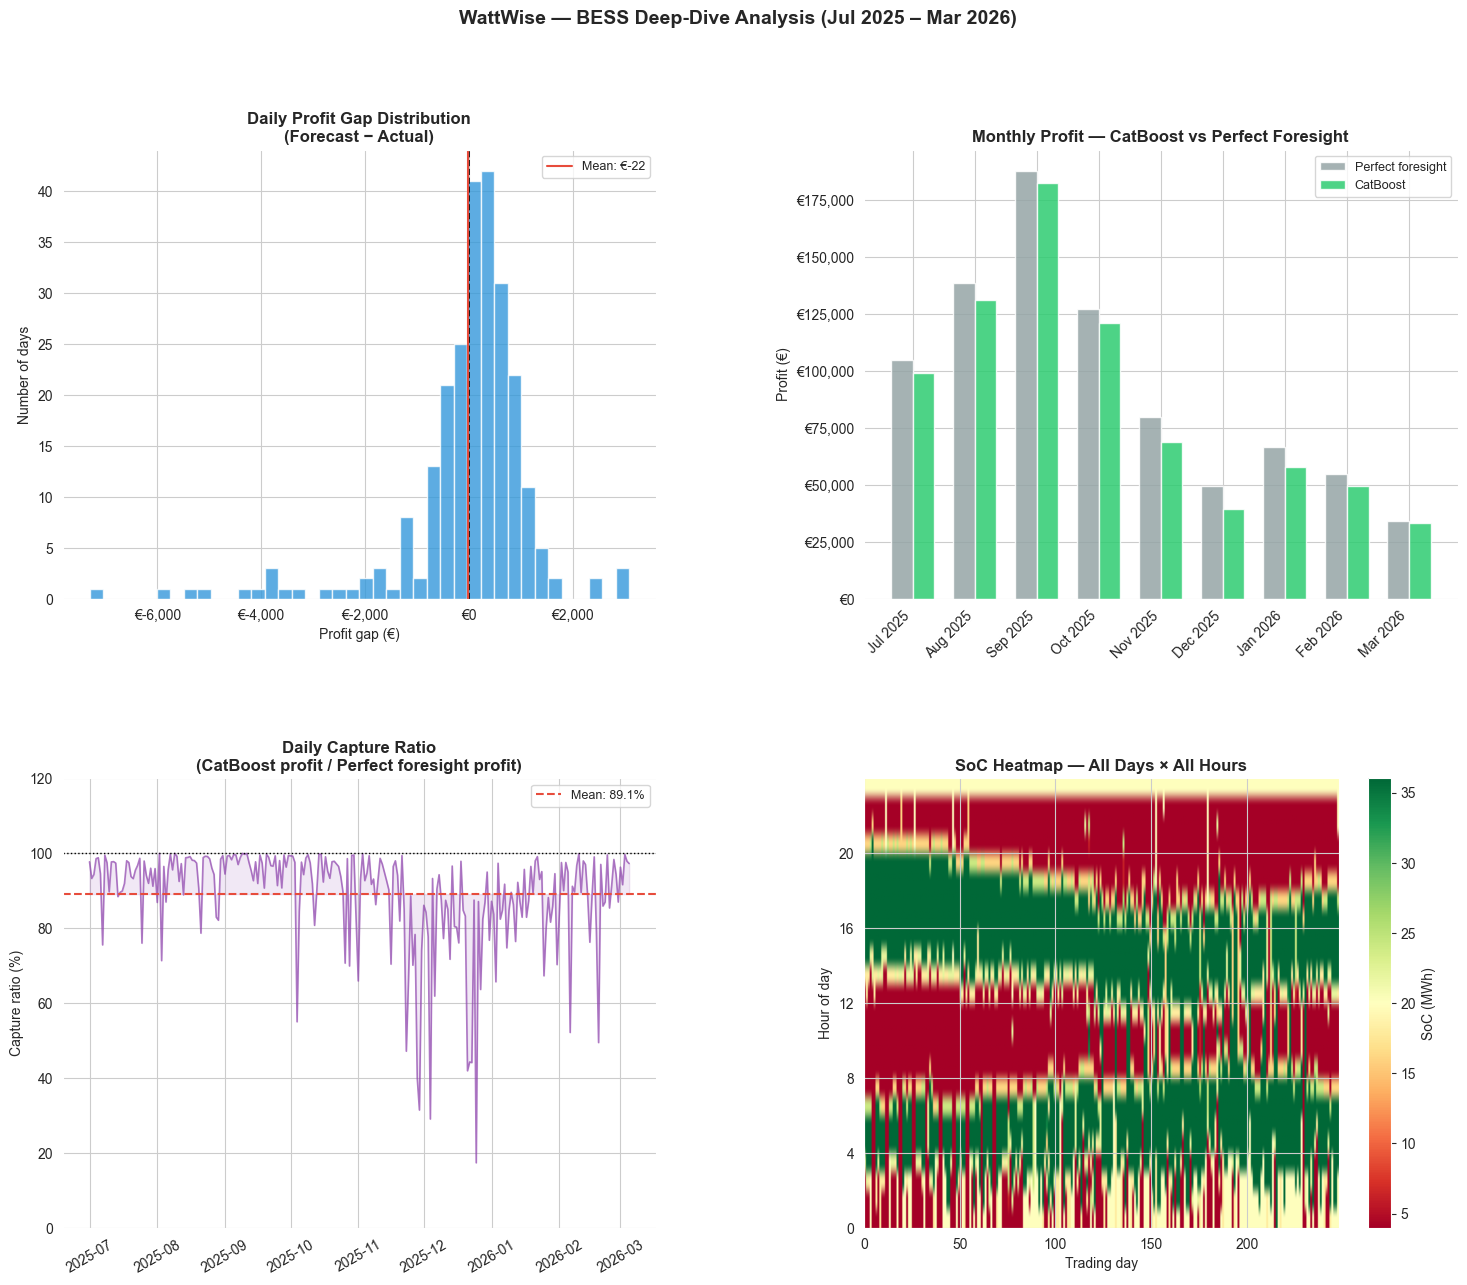

Plot saved → results/plots/bess_deepdive.png


In [96]:
# ================================================================
# ADDITIONAL VISUALISATIONS
# ================================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import calendar

os.makedirs("results/plots", exist_ok=True)

fig = plt.figure(figsize=(18, 14))
fig.suptitle("WattWise — BESS Deep-Dive Analysis (Jul 2025 – Mar 2026)",
             fontsize=14, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.35)

# ── Panel 1: Profit gap distribution ─────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
gaps = backtest['profit_gap']
ax1.hist(gaps, bins=40, color='#3498db', alpha=0.8, edgecolor='white')
ax1.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax1.axvline(gaps.mean(), color='#e74c3c', linewidth=1.5,
            label=f"Mean: €{gaps.mean():,.0f}")
ax1.set_title("Daily Profit Gap Distribution\n(Forecast − Actual)", 
              fontweight='bold')
ax1.set_xlabel("Profit gap (€)")
ax1.set_ylabel("Number of days")
ax1.legend(fontsize=9)
ax1.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"€{x:,.0f}"))

# ── Panel 2: Monthly profit breakdown ────────────────────────
ax2 = fig.add_subplot(gs[0, 1])

combined.index = pd.to_datetime(combined.index)
monthly = combined.groupby(combined.index.to_period('M')).agg(
    actual_profit=('actual_profit', 'sum'),
    pf_profit=('pf_profit', 'sum'),
).reset_index()
monthly['month_str'] = monthly['date'].dt.strftime('%b %Y')

x = np.arange(len(monthly))
w = 0.35
ax2.bar(x - w/2, monthly['pf_profit'],     width=w, color='#95a5a6',
        alpha=0.85, label='Perfect foresight')
ax2.bar(x + w/2, monthly['actual_profit'], width=w, color='#2ecc71',
        alpha=0.85, label='CatBoost')
ax2.set_title("Monthly Profit — CatBoost vs Perfect Foresight",
              fontweight='bold')
ax2.set_ylabel("Profit (€)")
ax2.set_xticks(x)
ax2.set_xticklabels(monthly['month_str'], rotation=45, ha='right')
ax2.legend(fontsize=9)
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"€{x:,.0f}"))

# ── Panel 3: Daily capture ratio over time ───────────────────
ax3 = fig.add_subplot(gs[1, 0])
combined.index = pd.to_datetime(combined.index)
ax3.plot(combined.index, combined['capture_ratio'] * 100,
         color='#8e44ad', linewidth=1.2, alpha=0.7)
ax3.axhline(combined['capture_ratio'].mean() * 100,
            color='#e74c3c', linestyle='--', linewidth=1.5,
            label=f"Mean: {combined['capture_ratio'].mean():.1%}")
ax3.axhline(100, color='black', linestyle=':', linewidth=1.0)
ax3.fill_between(combined.index, combined['capture_ratio'] * 100,
                 combined['capture_ratio'].mean() * 100,
                 alpha=0.12, color='#8e44ad')
ax3.set_title("Daily Capture Ratio\n(CatBoost profit / Perfect foresight profit)",
              fontweight='bold')
ax3.set_ylabel("Capture ratio (%)")
ax3.set_ylim(0, 120)
ax3.tick_params(axis='x', rotation=30)
ax3.legend(fontsize=9)

# ── Panel 4: SoC heatmap across all days ─────────────────────
ax4 = fig.add_subplot(gs[1, 1])

# Re-run optimizer to collect hourly SoC for every day
soc_matrix = []
soc_dates  = []
current_soc_hm = optimizer.config.initial_soc_mwh

for date in test_dates:
    mask     = y_test_pred_catboost.index.normalize() == date
    forecast = y_test_pred_catboost[mask]
    if len(forecast) != 24:
        continue
    res = optimizer.optimize(forecast, initial_soc_mwh=current_soc_hm)
    if res['status'] != 'Optimal':
        continue
    soc_matrix.append(res['schedule']['soc_mwh'].values)
    soc_dates.append(date)
    current_soc_hm = res['schedule']['soc_mwh'].iloc[-1]

soc_array = np.array(soc_matrix)   # shape: (days, 24)

im = ax4.imshow(soc_array.T, aspect='auto', origin='lower',
                cmap='RdYlGn', vmin=4, vmax=36,
                extent=[0, len(soc_dates), 0, 24])
plt.colorbar(im, ax=ax4, label='SoC (MWh)')
ax4.set_title("SoC Heatmap — All Days × All Hours",
              fontweight='bold')
ax4.set_xlabel("Trading day")
ax4.set_ylabel("Hour of day")
ax4.set_yticks(range(0, 24, 4))

plt.savefig("results/plots/bess_deepdive.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → results/plots/bess_deepdive.png")

# Battery Simulation

In [75]:
import pulp
print(pulp.__version__)
solver = pulp.PULP_CBC_CMD()
print("CBC solver available:", solver.available())

3.3.0
CBC solver available: /Users/christophbueckle/Documents/neuefische/capstone/WattWise/.venv/lib/python3.11/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc


In [76]:
# src/optimization/bess_optimizer.py

from __future__ import annotations
from dataclasses import dataclass
import pandas as pd
import pulp

### initial_soc is set to 50% as a day-1 default. From day 2 onwards, your code will pass in yesterday's ending SoC instead — the dataclass doesn't need to change, the optimizer just receives a different value each day.
### The @property fields compute the MWh equivalents on demand. This means you only ever edit the percentages at the top, and the MWh numbers update automatically — no risk of them getting out of sync.

In [81]:
import os
import pulp
import numpy as np
import pandas as pd
from dataclasses import dataclass


@dataclass
class BESSConfig:
    """Physical and operational parameters of the battery system."""

    capacity_mwh: float = 40.0
    power_mw: float     = 20.0
    efficiency: float   = 0.90
    soc_min: float      = 0.10
    soc_max: float      = 0.90
    initial_soc: float  = 0.50

    @property
    def soc_min_mwh(self) -> float:
        return self.soc_min * self.capacity_mwh

    @property
    def soc_max_mwh(self) -> float:
        return self.soc_max * self.capacity_mwh

    @property
    def initial_soc_mwh(self) -> float:
        return self.initial_soc * self.capacity_mwh


class BESSOptimizer:
    """
    Day-ahead BESS dispatch optimizer using Linear Programming.

    Given a 24-hour price forecast, finds the charge/discharge schedule
    that maximises arbitrage profit subject to physical battery constraints.
    """

    def __init__(self, config: BESSConfig | None = None):
        self.config = config or BESSConfig()

    def optimize(
        self,
        prices: pd.Series,
        initial_soc_mwh: float | None = None,
    ) -> dict:
        cfg = self.config
        T   = 24
        soc_0 = initial_soc_mwh if initial_soc_mwh is not None \
                else cfg.initial_soc_mwh

        prob = pulp.LpProblem("BESS_DayAhead_Arbitrage", pulp.LpMaximize)

        c = [pulp.LpVariable(f"charge_{t}",    lowBound=0, upBound=cfg.power_mw)    for t in range(T)]
        d = [pulp.LpVariable(f"discharge_{t}", lowBound=0, upBound=cfg.power_mw)    for t in range(T)]
        s = [pulp.LpVariable(f"soc_{t}",       lowBound=cfg.soc_min_mwh, upBound=cfg.soc_max_mwh) for t in range(T)]

        prob += pulp.lpSum(
            prices.iloc[t] * d[t] - prices.iloc[t] * c[t]
            for t in range(T)
        )

        prob += s[0] == soc_0 + cfg.efficiency * c[0] - d[0]
        for t in range(1, T):
            prob += s[t] == s[t-1] + cfg.efficiency * c[t] - d[t]

        prob += s[T-1] == soc_0

        solver = pulp.PULP_CBC_CMD(msg=0)
        prob.solve(solver)

        status   = pulp.LpStatus[prob.status]
        schedule = pd.DataFrame({
            "datetime":       prices.index,
            "price":          prices.values,
            "charge_mw":      [pulp.value(c[t]) for t in range(T)],
            "discharge_mw":   [pulp.value(d[t]) for t in range(T)],
            "soc_mwh":        [pulp.value(s[t]) for t in range(T)],
        }).set_index("datetime")

        schedule["net_mw"]   = schedule["discharge_mw"] - schedule["charge_mw"]
        schedule["pnl_eur"]  = (
            schedule["price"] * schedule["discharge_mw"]
            - schedule["price"] * schedule["charge_mw"]
        )

        return {
            "status":   status,
            "profit":   schedule["pnl_eur"].sum(),
            "schedule": schedule,
        }

    def save_schedule(
        self,
        schedule: pd.DataFrame,
        date: str,
        output_dir: str = "results/scores",
    ) -> str:
        os.makedirs(output_dir, exist_ok=True)
        path = os.path.join(output_dir, f"bess_schedule_{date}.csv")
        schedule.to_csv(path)
        print(f"Schedule saved → {path}")
        return path

    def simulate(
        self,
        schedule: pd.DataFrame,
        actual_prices: pd.Series,
    ) -> dict:
        result = schedule.copy()
        result["actual_price"] = actual_prices.values
        result["actual_pnl_eur"] = (
            result["actual_price"] * result["discharge_mw"]
            - result["actual_price"] * result["charge_mw"]
        )

        actual_profit   = result["actual_pnl_eur"].sum()
        forecast_profit = result["pnl_eur"].sum()

        return {
            "actual_profit":   actual_profit,
            "forecast_profit": forecast_profit,
            "profit_gap":      forecast_profit - actual_profit,
            "schedule":        result,
        }

In [82]:
np.random.seed(42)
hours = pd.date_range("2025-07-01", periods=24, freq="h")

base = np.array([
    30, 25, 22, 20, 21, 28,
    55, 75, 80, 70, 60, 55,
    50, 48, 50, 55, 65, 85,
    90, 80, 65, 55, 45, 35,
], dtype=float)

forecast_prices = pd.Series(base + np.random.normal(0, 3, 24), index=hours)
actual_prices   = pd.Series(base + np.random.normal(0, 8, 24), index=hours)

optimizer = BESSOptimizer(BESSConfig())
result    = optimizer.optimize(forecast_prices, initial_soc_mwh=20.0)

print(f"Solver status   : {result['status']}")
print(f"Forecast profit : €{result['profit']:,.2f}")
print()
print(result['schedule'].to_string())

Solver status   : Optimal
Forecast profit : €2,913.01

                         price  charge_mw  discharge_mw  soc_mwh     net_mw      pnl_eur
datetime                                                                                
2025-07-01 00:00:00  31.490142   0.000000          16.0      4.0  16.000000   503.842279
2025-07-01 01:00:00  24.585207   0.000000           0.0      4.0   0.000000     0.000000
2025-07-01 02:00:00  23.943066  15.555556           0.0     18.0 -15.555556  -372.447698
2025-07-01 03:00:00  24.569090   0.000000           0.0     18.0   0.000000     0.000000
2025-07-01 04:00:00  20.297540  20.000000           0.0     36.0 -20.000000  -405.950798
2025-07-01 05:00:00  27.297589   0.000000           0.0     36.0   0.000000     0.000000
2025-07-01 06:00:00  59.737638   0.000000           0.0     36.0   0.000000     0.000000
2025-07-01 07:00:00  77.302304   0.000000          12.0     24.0  12.000000   927.627650
2025-07-01 08:00:00  78.591577   0.000000          20.0

In [83]:
sim = optimizer.simulate(result['schedule'], actual_prices)

print(f"Forecast profit : €{sim['forecast_profit']:,.2f}")
print(f"Actual profit   : €{sim['actual_profit']:,.2f}")
print(f"Profit gap      : €{sim['profit_gap']:,.2f}")

optimizer.save_schedule(result['schedule'], date="2025-07-01")

Forecast profit : €2,913.01
Actual profit   : €3,349.53
Profit gap      : €-436.51
Schedule saved → results/scores/bess_schedule_2025-07-01.csv


'results/scores/bess_schedule_2025-07-01.csv'

In [100]:
# ================================================================
# SINGLE-DAY OPTIMIZER — run for any date in the test set
# ================================================================

def run_optimizer(date: str) -> pd.DataFrame:
    """
    Run the BESS optimizer for a single day using CatBoost forecasts.

    Parameters
    ----------
    date : str
        Date string in 'YYYY-MM-DD' format. Must be in the test set
        (2025-07-01 → 2026-03-05).

    Returns
    -------
    pd.DataFrame : hourly schedule with prices, actions, SoC and P&L.
    """
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec

    # --- validate and parse date ---
    target = pd.Timestamp(date)
    available = y_test_pred_catboost.index.normalize().unique()

    if target not in available:
        print(f"Date {date} not found in test set.")
        print(f"Available range: {available[0].date()} → {available[-1].date()}")
        return None

    # --- slice forecast and actuals ---
    mask     = y_test_pred_catboost.index.normalize() == target
    forecast = y_test_pred_catboost[mask]
    actual   = y_test_indexed[mask]

    if len(forecast) != 24:
        print(f"Incomplete data for {date} — only {len(forecast)} hours found.")
        return None

    # --- run optimizer ---
    opt    = BESSOptimizer(BESSConfig())
    result = opt.optimize(forecast, initial_soc_mwh=20.0)
    sim    = opt.simulate(result['schedule'], actual)
    sched  = sim['schedule']

    # --- print summary ---
    print(f"{'='*52}")
    print(f"  WattWise BESS Schedule — {date}")
    print(f"{'='*52}")
    print(f"  Solver status    : {result['status']}")
    print(f"  Forecast profit  : €{sim['forecast_profit']:>10,.2f}")
    print(f"  Actual profit    : €{sim['actual_profit']:>10,.2f}")
    print(f"  Profit gap       : €{sim['profit_gap']:>10,.2f}")
    print(f"{'='*52}\n")

    # --- print schedule table ---
    display_cols = ['price', 'actual_price', 'charge_mw',
                    'discharge_mw', 'soc_mwh', 'actual_pnl_eur']
    print(sched[display_cols].to_string(
        float_format=lambda x: f"{x:8.2f}"
    ))

    # --- plot ---
    hours = range(24)
    fig   = plt.figure(figsize=(14, 9))
    fig.suptitle(f"WattWise BESS — Single Day Schedule: {date}",
                 fontsize=13, fontweight='bold')

    gs = gridspec.GridSpec(2, 2, figure=fig,
                           hspace=0.40, wspace=0.35)

    # Panel 1: Prices (forecast vs actual)
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(hours, forecast.values, color='#f39c12', linewidth=2,
             linestyle='--', label='CatBoost forecast', zorder=3)
    ax1.plot(hours, actual.values, color='#2c3e50', linewidth=2,
             label='Actual price', zorder=3)
    ax1.set_title("Price Forecast vs Actual (€/MWh)", fontweight='bold')
    ax1.set_ylabel("Price (€/MWh)")
    ax1.set_xlabel("Hour")
    ax1.set_xticks(hours)
    ax1.legend(fontsize=9)
    ax1.grid(axis='y', alpha=0.3)

    # Shade charge hours in blue, discharge hours in red
    for t in hours:
        if sched['charge_mw'].iloc[t] > 0.01:
            ax1.axvspan(t - 0.5, t + 0.5, alpha=0.12,
                        color='#3498db', zorder=1)
        elif sched['discharge_mw'].iloc[t] > 0.01:
            ax1.axvspan(t - 0.5, t + 0.5, alpha=0.12,
                        color='#e74c3c', zorder=1)

    # Panel 2: Charge / discharge bars
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.bar(hours, sched['discharge_mw'], color='#e74c3c',
            alpha=0.8, label='Discharge (MW)', width=0.4, align='edge')
    ax2.bar(hours, [-c for c in sched['charge_mw']], color='#3498db',
            alpha=0.8, label='Charge (MW)', width=-0.4, align='edge')
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_title("Charge / Discharge Schedule (MW)", fontweight='bold')
    ax2.set_ylabel("Power (MW)")
    ax2.set_xlabel("Hour")
    ax2.set_xticks(hours)
    ax2.legend(fontsize=9)
    ax2.grid(axis='y', alpha=0.3)

    # Panel 3: SoC curve
    ax3 = fig.add_subplot(gs[1, 1])
    soc = sched['soc_mwh'].values
    ax3.plot(hours, soc, color='#27ae60', linewidth=2.2,
             marker='o', markersize=4)
    ax3.fill_between(hours, soc,
                     BESSConfig().soc_min_mwh,
                     alpha=0.15, color='#27ae60')
    ax3.axhline(BESSConfig().soc_max_mwh, color='#e74c3c',
                linestyle=':', linewidth=1.2, label='SoC max (36 MWh)')
    ax3.axhline(BESSConfig().soc_min_mwh, color='#3498db',
                linestyle=':', linewidth=1.2, label='SoC min (4 MWh)')
    ax3.axhline(20.0, color='#7f8c8d', linestyle='--',
                linewidth=1.0, label='Start/end (20 MWh)')
    ax3.set_title("State of Charge (MWh)", fontweight='bold')
    ax3.set_ylabel("SoC (MWh)")
    ax3.set_xlabel("Hour")
    ax3.set_xticks(hours)
    ax3.set_ylim(0, 40)
    ax3.legend(fontsize=9)
    ax3.grid(axis='y', alpha=0.3)

    os.makedirs("results/plots", exist_ok=True)
    plt.savefig(f"results/plots/bess_schedule_{date}.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nPlot saved → results/plots/bess_schedule_{date}.png")

    return sched

Running optimizer for: 2026-03-03
  WattWise BESS Schedule — 2026-03-03
  Solver status    : Optimal
  Forecast profit  : €  6,945.99
  Actual profit    : €  6,269.42
  Profit gap       : €    676.57

                       price  actual_price  charge_mw  discharge_mw  soc_mwh  actual_pnl_eur
datetime                                                                                    
2026-03-03 00:00:00    91.23         89.06       0.00          0.00    20.00            0.00
2026-03-03 01:00:00    88.72         90.12      17.78          0.00    36.00        -1602.13
2026-03-03 02:00:00    90.92         89.43       0.00          0.00    36.00            0.00
2026-03-03 03:00:00    91.15         92.82       0.00          0.00    36.00            0.00
2026-03-03 04:00:00    93.19         95.72       0.00          0.00    36.00            0.00
2026-03-03 05:00:00   105.39        103.32       0.00          0.00    36.00            0.00
2026-03-03 06:00:00   138.59        136.05       0.00  

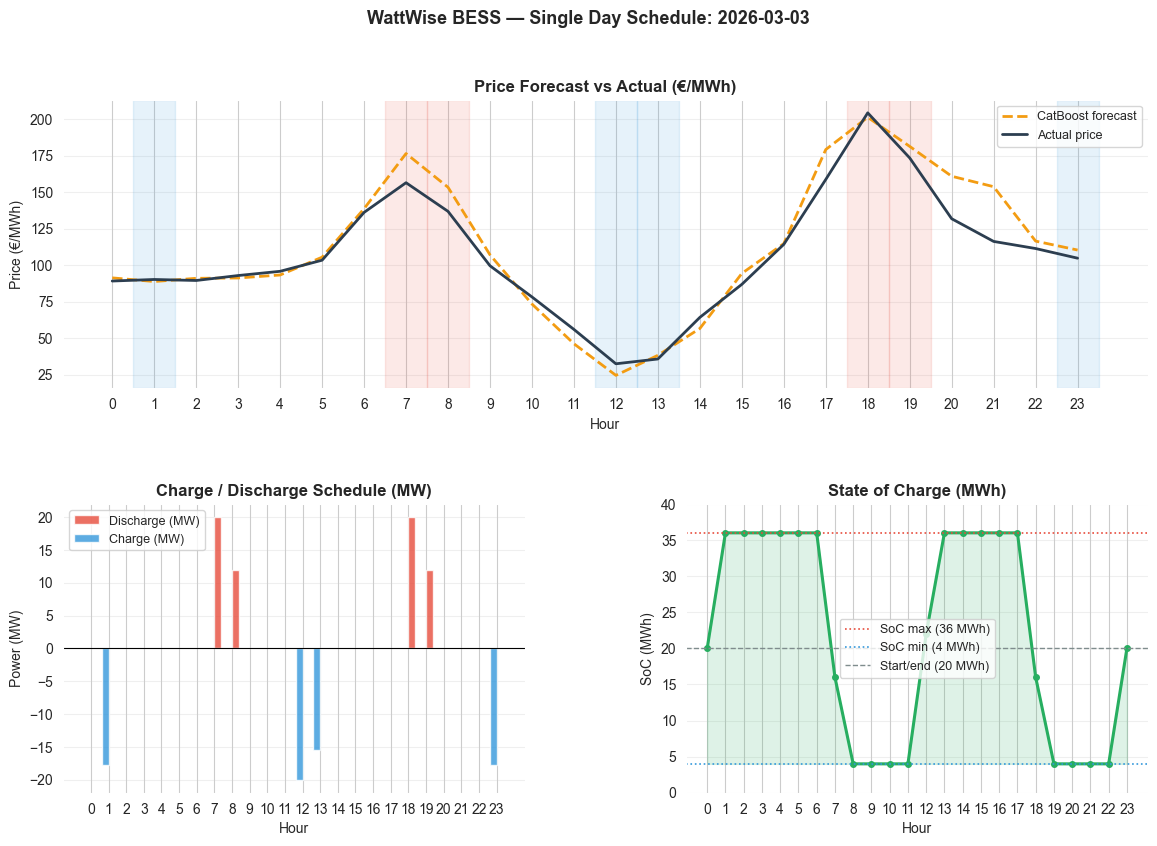


Plot saved → results/plots/bess_schedule_2026-03-03.png


In [103]:
import random
random_date = str(random.choice(test_dates).date())
print(f"Running optimizer for: {random_date}")
schedule = run_optimizer(date=random_date)